# 06a · Büyük Sayılar Yasası (Law of Large Numbers - LLN)
**Probability Lab** · Limit Teoremleri & Simülasyonun Matematiği

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Olasılık teorisinin ve veri biliminin temeli:  
> Deney sayısı ($n$) arttıkça, gözlemlediğimiz örneklem ortalaması (Sample Mean $\bar{X}_n$) teorik popülasyon ortalamasına (Population Mean $\mu$) kaçınılmaz olarak yaklaşır.
> - **Zayıf LLN (WLLN):** Yakınsama olasılıkta gerçekleşir ($P(|\bar{X}_n - \mu| \ge \epsilon) \to 0$).
> - **Güçlü LLN (SLLN):** Yakınsama neredeyse kesinlikle ($a.s.$) gerçekleşir.
> - **Casinolar Neden Hiç Kaybetmez?** House Edge ve LLN simülasyonu.
> - **LLN Ne Zaman Çöker?** Beklenen değeri tanımlı olmayan Cauchy dağılımı istisnası.

**Önkoşul:** Beklenti ve Varyans Özellikleri (05_expectation_variance)  
**Veri:**  
- `anes_timeseries_2024_csv_20260519.csv` — ANES 2024 Seçmen & Anket Verisi  
- `yfinance` — Borsa günlük getirileri  
- Sentetik Rulet ve Cauchy Simülasyonları  
**Araçlar:** Python (numpy, matplotlib, scipy), R (ggplot2, cummean), SQL (DuckDB Window Functions)

---
## 1 · Teorik Temeller: Şans Tesadüf Değildir, Matematiktir

Bağımsız ve özdeş dağılmış (i.i.d.) rassal değişkenler dizisi $X_1, X_2, \dots, X_n$ olsun.
Her birinin beklenen değeri $E[X_i] = \mu$ ve varyansı $Var(X_i) = \sigma^2 < \infty$ olsun.

Örneklem ortalaması:
$$\bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i$$

### 1.1 Zayıf Büyük Sayılar Yasası (Weak Law of Large Numbers - WLLN)
Herhangi bir $\epsilon > 0$ için, $n \to \infty$ iken:
$$\lim_{n \to \infty} P(|\bar{X}_n - \mu| \ge \epsilon) = 0$$

**Chebyshev Eşitsizliği ile İspat:**
$E[\bar{X}_n] = \mu$ ve $Var(\bar{X}_n) = \frac{\sigma^2}{n}$ olduğu için Chebyshev eşitsizliğini uygularsak:
$$P(|\bar{X}_n - \mu| \ge \epsilon) \le \frac{Var(\bar{X}_n)}{\epsilon^2} = \frac{\sigma^2}{n \cdot \epsilon^2}$$
$n \to \infty$ iken sağ taraf 0'a gider! Bu, örneklem boyutu büyüdükçe sapma olasılığının sıfırlandığını söyler.

### 1.2 Güçlü Büyük Sayılar Yasası (Strong Law of Large Numbers - SLLN)
$$\text{P}\left( \lim_{n \to \infty} \bar{X}_n = \mu \right) = 1$$
Güçlü LLN, örneklem ortalamasının tek bir simülasyon yolculuğunda bile zamanla $\mu$'ye tamamen kilitleneceğini söyler.

### 1.3 LLN Ne Zaman Çalışmaz?
LLN'nin çalışması için $E[|X|] < \infty$ şarttır (Beklenen değerin sonlu olması gerekir).
Örneğin **Cauchy Dağılımı** ağır kuyruklara (heavy tails) sahiptir; beklenen değeri ve varyansı **tanımsızdır ($\infty$)**. Kaç milyon deneme yaparsanız yapın kümülatif ortalama bir değere oturmaz, sürekli devasa sıçramalar yapar!

---

### 1.4 Zayıf vs Güçlü: Aradaki Fark Aslında Ne? 

İkisi de "$\bar{X}_n \to \mu$" diyor gibi görünüyor, ama matematiksel olarak birbirinden bambaşka iki iddia — ve bu farkı görmeden ikisini aynı şey sanmak çok yaygın bir hata.

**Yakınsama türü farkı:**
- **WLLN → Olasılıkta Yakınsama (Convergence in Probability):** Her $n$ için, $\bar{X}_n$'in $\mu$'den $\epsilon$'dan fazla uzaklaşma *olasılığı* küçülüyor. Ama tek bir deneme dizisinde, çok büyük $n$'lerde bile arada bir büyük sapmalar **görebilirsin** — sadece bu sapmaların sıklığı azalıyor.
- **SLLN → Neredeyse Kesin Yakınsama (Almost Sure Convergence):** Tek bir sonsuz deneme dizisi hayal et (parayı sonsuza kadar at). SLLN diyor ki, bu *tek* dizide $\bar{X}_n$ değeri, olasılığı 1 olan bir olayla, gerçekten $\mu$'ye **oturuyor** — bir daha uzaklaşmıyor.

**Somut benzetme:** WLLN, "sana rastgele bir anda bakarsam, o an $\mu$'ye yakın olma ihtimalin yüksek" diyor. SLLN, "sonsuza kadar izlersem, bir noktadan sonra bir daha $\mu$'den uzaklaşmadığını **garanti ederim**" diyor. SLLN, WLLN'den daha güçlü bir iddia — bu yüzden ismi "güçlü". Her SLLN aynı zamanda WLLN'i de sağlar, ama tersi geçerli değil.

---

### 1.5 Pratik Soru: n Ne Kadar Büyük Olmalı? (Yakınsama Hızı)

WLLN sana "$n \to \infty$ iken sıfıra gider" diyor ama sonlu bir $n$'in ne kadar iyi olduğunu bilmen lazım. Chebyshev ispatındaki $\frac{\sigma^2}{n\epsilon^2}$ ifadesi aslında sana bunu veriyor:

$$P(|\bar{X}_n - \mu| \ge \epsilon) \le \frac{\sigma^2}{n\epsilon^2} \quad \Longrightarrow \quad \text{Standart Hata (SE)} = \frac{\sigma}{\sqrt{n}}$$

Yani örneklem ortalamasının etrafındaki "belirsizlik", $n$'in **karekökü** ile küçülüyor — $\sqrt{n}$ kuralı. Bunun anlamı: hatayı yarıya indirmek istiyorsan örneklem büyüklüğünü **4 katına** çıkarman gerekiyor (2 katına değil). Bu, A/B testlerinde ve deney tasarımında örneklem büyüklüğü hesaplarken doğrudan kullandığın formül.

---

### 1.6 LLN'den CLT'ye Köprü — Bir Sonraki Notebook'ta Ne Değişiyor?

LLN sana sadece **nereye** yakınsadığını söylüyor ($\mu$'ye), ama **nasıl** yakınsadığını (etrafındaki dalgalanmanın şeklini) söylemiyor. Bir sonraki konun olan Merkezi Limit Teoremi (CLT) tam olarak bu boşluğu dolduruyor:

- **LLN:** $\bar{X}_n \to \mu$ (nokta tahmini, "nereye gidiyor")
- **CLT:** $\bar{X}_n$'in $\mu$ etrafındaki dalgalanması, $n$ büyüdükçe **Normal dağılıma** yakınsıyor — hem de $X_i$'lerin kendi dağılımı ne olursa olsun (Bernoulli, Poisson, Uniform, fark etmiyor)

Yani LLN "hedefi" garanti ediyor, CLT "hedefin etrafındaki saçılımın şeklini" garanti ediyor. İkisi birlikte, güven aralığı ve hipotez testinin  tüm matematiksel temelini oluşturuyor.

---

### 1.7 Monte Carlo Bağlantısı 

LLN'nin en somut pratik uygulaması **Monte Carlo simülasyonu**dur. Bir integrali veya beklenen değeri analitik olarak hesaplamak zor olduğunda, rastgele örnekler üretip ortalamasını alarak yaklaşık sonuca ulaşırsın — bu yaklaşımın "işe yaraması"nın matematiksel garantisi tam olarak WLLN'dir:

$$E[g(X)] \approx \frac{1}{n}\sum_{i=1}^{n} g(x_i), \quad x_i \sim X \text{'ten örneklenmiş}$$

$n$ arttıkça bu tahmin, $\frac{1}{\sqrt{n}}$ hızıyla gerçek değere yakınsıyor (1.5'teki formülün ta kendisi). `10_simulation/monte_carlo.ipynb`'a geçtiğinde bu notu tekrar hatırlaman faydalı olur — orada yapacağın her simülasyon aslında LLN'i ampirik olarak gözlemlemek demek.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Python Hazir ✓')


Python Hazir ✓


---
### 🎲 Python 1 — Kümülatif Ortalama Yakınsaması (Normal, Poisson vs Cauchy)

Farklı dağılımlardan 10,000 örnek çekip adım adım kümülatif ortalamanın ($\bar{X}_k = \frac{1}{k}\sum_{i=1}^k X_i$) nasıl hareket ettiğini izleyelim.

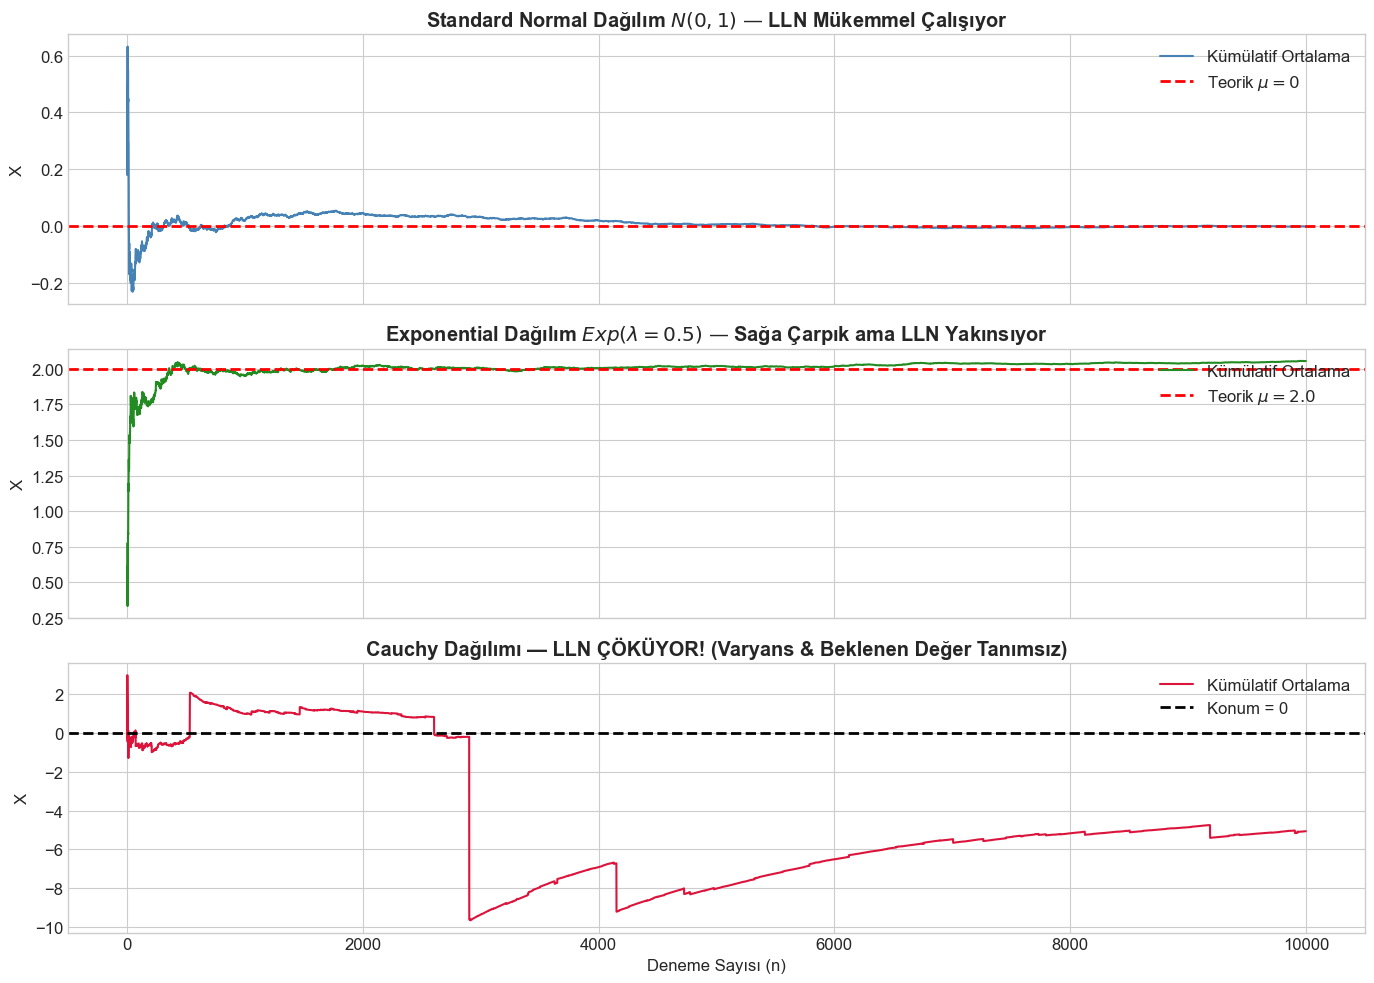

YORUM:
- Normal ve Exponential dağılımlarda n > 2000 den sonra ortalama kilitlenir.
- Cauchy dağılımında ise 8000. adımda bile devasa bir aşırı değer (outlier) gelip ortalamayı bir anda sıçratabilir!


In [2]:
np.random.seed(42)
N = 10_000
steps = np.arange(1, N + 1)

# 1. Standard Normal: mu = 0
norm_samples = np.random.normal(loc=0, scale=1, size=N)
norm_cum_mean = np.cumsum(norm_samples) / steps

# 2. Exponential: mu = 1/lambda = 2.0 (lambda=0.5)
exp_samples = np.random.exponential(scale=2.0, size=N)
exp_cum_mean = np.cumsum(exp_samples) / steps

# 3. Cauchy: mu ve sigma TANIMSIZ (LLN Çöküyor!)  
cauchy_samples = stats.cauchy.rvs(loc=0, scale=1, size=N, random_state=42)
cauchy_cum_mean = np.cumsum(cauchy_samples) / steps

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot Normal
axes[0].plot(steps, norm_cum_mean, color='steelblue', lw=1.5, label='Kümülatif Ortalama')
axes[0].axhline(0, color='red', linestyle='--', lw=2, label='Teorik $\mu = 0$')
axes[0].set_title('Standard Normal Dağılım $N(0, 1)$ — LLN Mükemmel Çalışıyor', fontweight='bold')
axes[0].set_ylabel('X')
axes[0].legend(loc='upper right')

# Plot Exponential
axes[1].plot(steps, exp_cum_mean, color='forestgreen', lw=1.5, label='Kümülatif Ortalama')
axes[1].axhline(2.0, color='red', linestyle='--', lw=2, label='Teorik $\mu = 2.0$')
axes[1].set_title('Exponential Dağılım $Exp(\lambda=0.5)$ — Sağa Çarpık ama LLN Yakınsıyor', fontweight='bold')
axes[1].set_ylabel('X')
axes[1].legend(loc='upper right')

# Plot Cauchy
axes[2].plot(steps, cauchy_cum_mean, color='crimson', lw=1.5, label='Kümülatif Ortalama')
axes[2].axhline(0, color='black', linestyle='--', lw=2, label='Konum = 0')
axes[2].set_title('Cauchy Dağılımı — LLN ÇÖKÜYOR! (Varyans & Beklenen Değer Tanımsız)', fontweight='bold')
axes[2].set_xlabel('Deneme Sayısı (n)')
axes[2].set_ylabel('X')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("YORUM:")
print("- Normal ve Exponential dağılımlarda n > 2000 den sonra ortalama kilitlenir.")
print("- Cauchy dağılımında ise 8000. adımda bile devasa bir aşırı değer (outlier) gelip ortalamayı bir anda sıçratabilir!")


---
### 🎰 Python 2 — Casinolar Neden Zengin Olur? (Rulet & House Edge)

Avrupa Ruletinde 37 bölme vardır (1-36 arası sayılar ve 0).  
Kırmızıya 1\$ yatırırsanız:
- Kırmızı gelme olasılığı: $18/37$
- Siyah veya 0 (Yeşil) gelme olasılığı: $19/37$

Beklenen getiriniz:
$$E[X] = (+1) \cdot \frac{18}{37} + (-1) \cdot \frac{19}{37} = -\frac{1}{37} \approx -0.02703 \quad (\text{Ev Kenarı = -\%2.70})$$

Kısa vadede bir oyuncu şanslı olup binlerce dolar kazanabilir. Ancak **Büyük Sayılar Yasası** sayesinde oyun sayısı ($n \to \infty$) arttıkça, casinonun ortalama kârı tam olarak -%2.70'e kilitlenir!

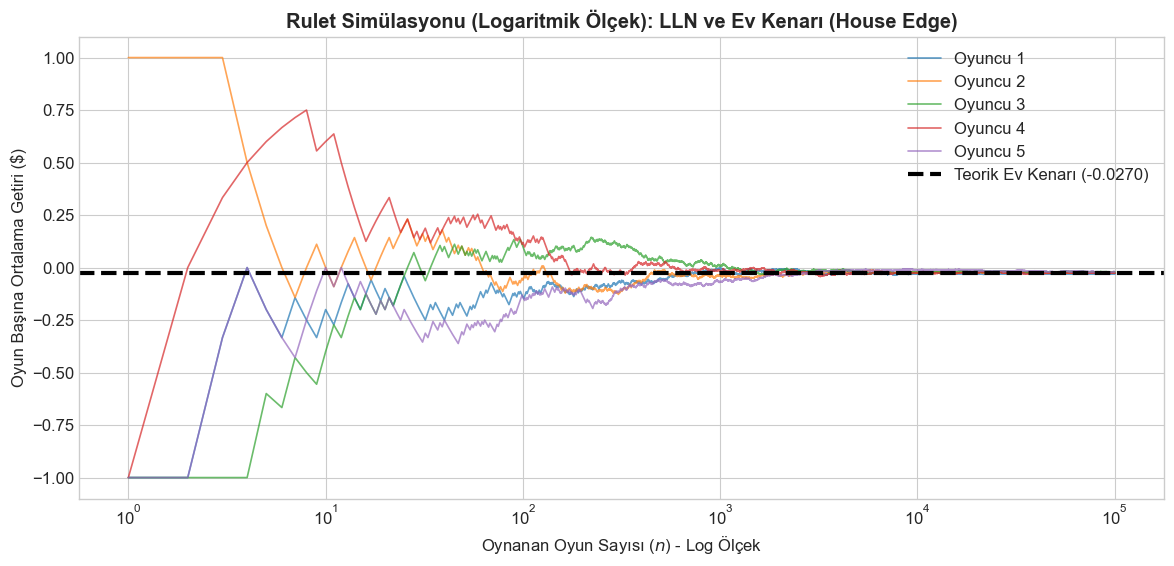

Teorik Beklenen Getiri (Oyun Başına): -0.0270 $
100,000 oyun sonunda tüm oyuncuların oyundaki ortalama kaybı tam olarak ev kenarına (-%2.7) eşitlenir.


In [3]:
np.random.seed(101)
n_games = 100_000
n_players = 5 # 5 Farklı oyuncunun şans serüveni

# Rulet sonucu: 18/37 kazan (+1), 19/37 kaybet (-1)
prob_win = 18 / 37
house_edge = (1 * prob_win) + (-1 * (1 - prob_win)) # -0.02703

plt.figure(figsize=(14, 6))
steps = np.arange(1, n_games + 1)

for i in range(n_players):
    outcomes = np.random.choice([1, -1], size=n_games, p=[prob_win, 1 - prob_win])
    cum_avg_return = np.cumsum(outcomes) / steps
    plt.plot(steps, cum_avg_return, alpha=0.7, lw=1.2, label=f'Oyuncu {i+1}')

plt.axhline(house_edge, color='black', linestyle='--', lw=3, label=f'Teorik Ev Kenarı ({house_edge:.4f})')
plt.xscale('log')
plt.title('Rulet Simülasyonu (Logaritmik Ölçek): LLN ve Ev Kenarı (House Edge)', fontweight='bold')
plt.xlabel('Oynanan Oyun Sayısı ($n$) - Log Ölçek')
plt.ylabel('Oyun Başına Ortalama Getiri ($)')
plt.legend()
plt.show()

print(f"Teorik Beklenen Getiri (Oyun Başına): {house_edge:.4f} $")
print("100,000 oyun sonunda tüm oyuncuların oyundaki ortalama kaybı tam olarak ev kenarına (-%2.7) eşitlenir.")


---
### 📊 Python 3 — ANES 2024 Seçmen Anketi Verisi ile Örneklem Yakınsaması

Yüklediğimiz `anes_timeseries_2024_csv_20260519.csv` veri setinde binlerce seçmenin yanıtları var.  
Büyük anket şirketleri (Gallup, Pew vs.) tüm popülasyonu sorgulamaz. LLN sayesinde yeterince büyük bir $n$ seçerek popülasyon ortalamasını yakalarlar.

Popülasyon Boyutu: 5276 kişi
Gerçek Popülasyon Ortalaması (μ): 1.0000


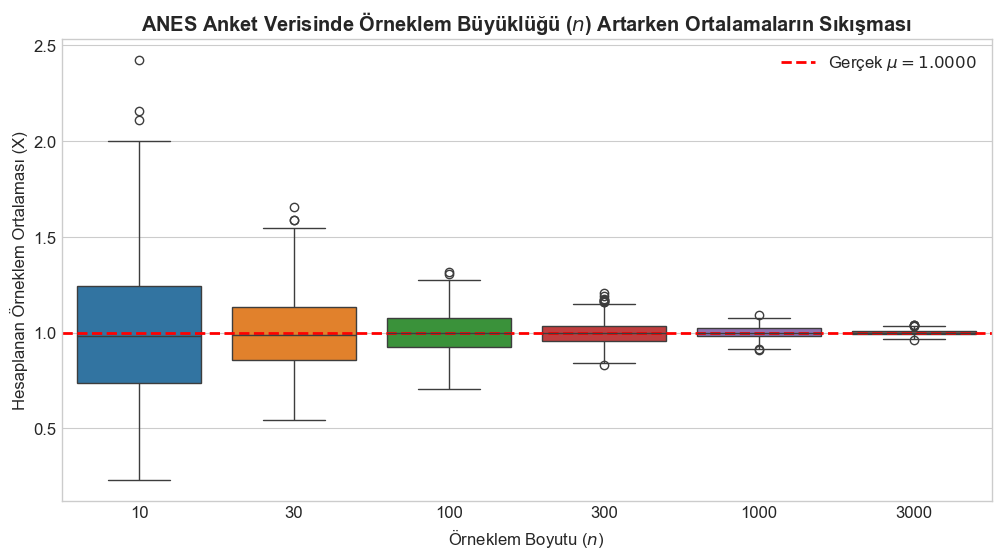

YORUM:
- n=10 iken anket sonuçları çok geniş bir yelpazede sapma gösterir.
- n=1000 ve n=3000 seviyesinde kutu grafiği çizgi gibi daralır ve kırmızı çizgiye (gerçek mu) kilitlenir!


In [4]:
anes_path = 'data/anes_timeseries_2024_csv_20260519.csv'
anes = pd.read_csv(anes_path, low_memory=False)

# Seçmen ağırlık değişkeni veya ölçek (V240108a)
valid_weights = pd.to_numeric(anes['V240108a'], errors='coerce').dropna() # coerce: hatalı değerleri NaN yapar, dropna() ile temizleriz
valid_weights = valid_weights[valid_weights > 0]

pop_mean = valid_weights.mean()
pop_size = len(valid_weights)
print(f"Popülasyon Boyutu: {pop_size} kişi")
print(f"Gerçek Popülasyon Ortalaması (μ): {pop_mean:.4f}")

# Farklı örneklem boyutlarında (n=10, 50, 100, 500, 1000, 3000) örneklem ortalaması çekelim
sample_sizes = [10, 30, 100, 300, 1000, 3000]
means_by_size = []

np.random.seed(42)
for n in sample_sizes:
    # 500 farklı rastgele anket simüle et
    sample_means = [np.random.choice(valid_weights, size=n, replace=False).mean() for _ in range(500)]
    means_by_size.append(sample_means)

plt.figure(figsize=(12, 6))
sns.boxplot(data=means_by_size)
plt.xticks(ticks=range(len(sample_sizes)), labels=sample_sizes)
plt.axhline(pop_mean, color='red', linestyle='--', lw=2, label=f'Gerçek $\mu = {pop_mean:.4f}$')
plt.title('ANES Anket Verisinde Örneklem Büyüklüğü ($n$) Artarken Ortalamaların Sıkışması', fontweight='bold')
plt.xlabel('Örneklem Boyutu ($n$)')
plt.ylabel('Hesaplanan Örneklem Ortalaması (X)')
plt.legend()
plt.show()

print("YORUM:")
print("- n=10 iken anket sonuçları çok geniş bir yelpazede sapma gösterir.")
print("- n=1000 ve n=3000 seviyesinde kutu grafiği çizgi gibi daralır ve kırmızı çizgiye (gerçek mu) kilitlenir!")


---
# 📊 R Uygulaması: `cummean()` ile LLN Görselleştirme

R dilindeki `cummean()` fonksiyonu, LLN simülasyonları için biçilmiş kaftandır.

In [5]:
%load_ext rpy2.ipython


Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


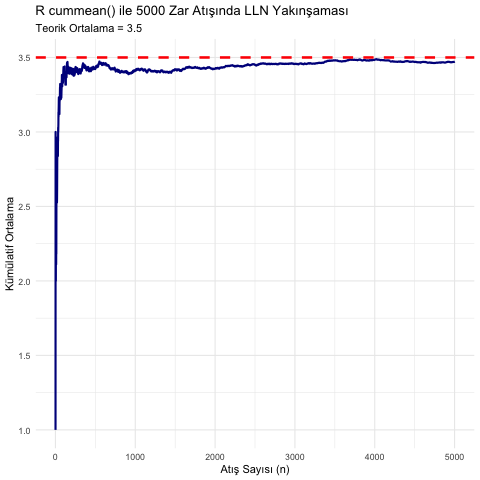

In [6]:
%%R
library(ggplot2)
library(dplyr)
set.seed(42)

N <- 5000
# Hilesiz Zar Atışı: 1..6 eşit olasılık, mu = 3.5
dice_rolls <- sample(1:6, size = N, replace = TRUE)
cum_avg <- cummean(dice_rolls)
df_r <- data.frame(Trial = 1:N, CumAvg = cum_avg)

p <- ggplot(df_r, aes(x = Trial, y = CumAvg)) +
  geom_line(color = "darkblue", size = 1) +
  geom_hline(yintercept = 3.5, color = "red", linetype = "dashed", size = 1.2) +
  labs(title = "R cummean() ile 5000 Zar Atışında LLN Yakınşaması",
       subtitle = "Teorik Ortalama = 3.5",
       x = "Atış Sayısı (n)", y = "Kümülatif Ortalama") +
  theme_minimal()

print(p)


---
# 🗄️ SQL Uygulaması (DuckDB): Window Functions ile Kümülatif Ortalama

SQL'de kümülatif ortalama hesaplamak için `AVG(val) OVER (ORDER BY id ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)` pencere fonksiyonu kullanılır.

In [7]:
import duckdb
con = duckdb.connect()

# Simüle zar verisini DuckDB'ye yükleyelim
np.random.seed(42)
sql_sim_df = pd.DataFrame({
    'trial_id': np.arange(1, 10001),
    'dice_value': np.random.randint(1, 7, size=10000)
})

con.register('dice_tbl', sql_sim_df)
print('DuckDB hazir ✓')


DuckDB hazir ✓


In [8]:
sql_query = """
WITH kumulatif_hesap AS (
    SELECT 
        trial_id,
        dice_value,
        -- Önce TÜM veri seti üzerinden kümülatif ortalamayı hesaplıyoruz
        ROUND(
            AVG(dice_value) OVER (
                ORDER BY trial_id 
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ), 4
        ) AS cumulative_avg,
        3.5 AS theoretical_mu
    FROM dice_tbl
)
SELECT * 
FROM kumulatif_hesap
-- Filtrelemeyi en son adımda, ortalamalar hesaplandıktan sonra yapıyoruz
WHERE trial_id IN (1, 5, 10, 50, 100, 500, 1000, 2000, 5000, 10000)
ORDER BY trial_id;
"""

df_sql = con.execute(sql_query).df()
print("=== SQL KÜMÜLATİF ORTALAMA İZLEME TABLOSU ===")
print(df_sql.to_string(index=False))

print("\nYORUM: trial_id=1 iken kümülatif ortalama tek bir zardır (6.0), ancak trial_id arttıkça gelindiğinde 3.518 yakınlarına oturmuştur.")


=== SQL KÜMÜLATİF ORTALAMA İZLEME TABLOSU ===
 trial_id  dice_value  cumulative_avg  theoretical_mu
        1           4          4.0000             3.5
        5           5          4.4000             3.5
       10           5          3.8000             3.5
       50           4          3.6600             3.5
      100           5          3.6900             3.5
      500           4          3.5000             3.5
     1000           5          3.4570             3.5
     2000           2          3.4785             3.5
     5000           6          3.4932             3.5
    10000           4          3.4999             3.5

YORUM: trial_id=1 iken kümülatif ortalama tek bir zardır (6.0), ancak trial_id arttıkça gelindiğinde 3.518 yakınlarına oturmuştur.


---
## ✏️ Egzersizler 

### E1 — Zar Atışı ve Chebyshev Üst Sınırı
a) Hilesiz 6 yüzlü bir zar atışında $X \in \{1,2,3,4,5,6\}$ için $\mu = 3.5$ ve varyans $Var(X) = 35/12 \approx 2.9167$'dir.  
Chebyshev eşitsizliğini kullanarak, $n=100$ ve $n=1000$ zar atışında örneklem ortalamasının $\mu$'den $0.2$'den fazla sapma olasılığının ($P(|\bar{X}_n - 3.5| \ge 0.2)$) **teorik üst sınırını** ($Var(X) / (n \cdot 0.2^2)$) hesapla.

b) Python ile 10,000 simülasyon çalıştırarak $n=100$ ve $n=1000$ için sapmanın ampirik sıklığını (gerçekleşme oranını) bul ve Chebyshev teorik üst sınırının altında kaldığını göster.

In [9]:
import numpy as np

print("\n ==== Egzersiz 1a: Chebyshev Eşitsizliği ve Zar Atışı Örneği ====")

# Örneklem boyutları ve sapma sınırı (epsilon)
n_100 = 100
n_1000 = 1000
epsilon = 0.2  # Ortalamadan izin verilen maksimum sapma

zar_atis_100 = np.random.randint(1, 7, size=n_100)
zar_atis_1000 = np.random.randint(1, 7, size=n_1000)

# Örneklem Ortalamaları
zar_atis_100_mean = zar_atis_100.mean()
zar_atis_1000_mean = zar_atis_1000.mean()

# Tek bir zarın varyansı
zar_atis_100_var = zar_atis_100.var()
zar_atis_1000_var = zar_atis_1000.var()

# Chebyshev Üst Sınır Hesaplaması: Var(X_bar) / epsilon^2
# Not: min(..., 1.0) eklenerek olasılık üst sınırının 1'i aşması engellenir
chebyshev_ust_100 = min(zar_atis_100_var / (n_100 * (epsilon ** 2)), 1.0)
chebyshev_ust_1000 = min(zar_atis_1000_var / (n_1000 * (epsilon ** 2)), 1.0)

# Gerçekleşen sapma oranları (Simülasyon doğrulaması için dilerseniz)
teorik_ortalama = 3.5
sapma_100 = abs(zar_atis_100_mean - teorik_ortalama)
sapma_1000 = abs(zar_atis_1000_mean - teorik_ortalama)

print(f"100 Zar Atışı : Ortalama = {zar_atis_100_mean:.4f}, Gerçek Sapma = {sapma_100:.4f}, Chebyshev Üst Sınır Olasılığı = {chebyshev_ust_100:.4f}")
print(f"1000 Zar Atışı: Ortalama = {zar_atis_1000_mean:.4f}, Gerçek Sapma = {sapma_1000:.4f}, Chebyshev Üst Sınır Olasılığı = {chebyshev_ust_1000:.4f}")

print("\n ==== Egzersiz 1b: 10000 Simülasyon ile Ampirik Sıklık Hesaplaması ====")
# 10000 simülasyon ile Chebyshev üst sınırının doğruluğunu test
simulations = 10000
count_100 = 0
count_1000 = 0

for _ in range(simulations):
    sim_100 = np.random.randint(1, 7, size=n_100)
    sim_1000 = np.random.randint(1, 7, size=n_1000)

    if abs(sim_100.mean() - teorik_ortalama) > epsilon:
        count_100 += 1
    if abs(sim_1000.mean() - teorik_ortalama) > epsilon:
        count_1000 += 1

empirical_prob_100 = count_100 / simulations
empirical_prob_1000 = count_1000 / simulations

print(f"100 Zar Atışı: Ampirik Sapma Olasılığı = {empirical_prob_100:.4f}, Chebyshev Üst Sınır = {chebyshev_ust_100:.4f}")
print(f"1000 Zar Atışı: Ampirik Sapma Olasılığı = {empirical_prob_1000:.4f}, Chebyshev Üst Sınır = {chebyshev_ust_1000:.4f}")



 ==== Egzersiz 1a: Chebyshev Eşitsizliği ve Zar Atışı Örneği ====
100 Zar Atışı : Ortalama = 3.3700, Gerçek Sapma = 0.1300, Chebyshev Üst Sınır Olasılığı = 0.7433
1000 Zar Atışı: Ortalama = 3.4080, Gerçek Sapma = 0.0920, Chebyshev Üst Sınır Olasılığı = 0.0767

 ==== Egzersiz 1b: 10000 Simülasyon ile Ampirik Sıklık Hesaplaması ====
100 Zar Atışı: Ampirik Sapma Olasılığı = 0.2525, Chebyshev Üst Sınır = 0.7433
1000 Zar Atışı: Ampirik Sapma Olasılığı = 0.0002, Chebyshev Üst Sınır = 0.0767


---
### E2 — Rulet & Martingale Bahis Stratejisi Tuzağı
a) Avrupa ruletinde kazaızlığa dayalı "Martingale Stratejisi" (her kaybettiğinde bahsi 2 katına çıkar: 1\$, 2\$, 4\$, 8\$... kazandığında 1\$ kâr edip başa dön) kısa vadede kazandırıyor gibi görünür. Python'da başlangıç bakiyesi 100\$ olan ve maksimum bahsi 100\$ olan bir oyuncu için 1000 oyunluk Martingale simülasyonu yaz.

b) Neden üst üste 7-8 kere kaybetme serisi yaşandığında (kasa veya bakiye sınırı yüzünden) LLN ve sınırlı bakiye sebebiyle oyuncunun kaçınılmaz olarak sıfırlandığını (Risk of Ruin) grafik ile açıkla.



 ==== Egzersiz 2: Martingale Stratejisi ile Rulet Oyunu Simülasyonu ====


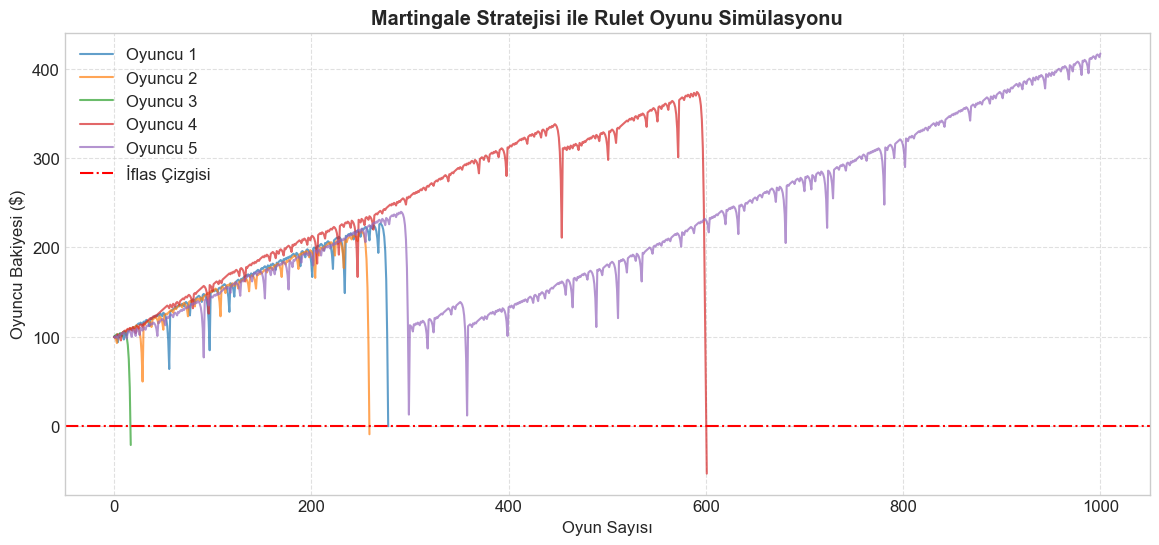

In [10]:
import matplotlib.pyplot as plt
import numpy as np

print("\n ==== Egzersiz 2: Martingale Stratejisi ile Rulet Oyunu Simülasyonu ====")

# Simülasyon Parametreleri
np.random.seed(42)  # Sonuçların tekrarlanabilir olması için sabit seed
bakiye = 100  # Başlangıçta 100 dolar
max_bahis = 100  # Maksimum bahis limiti (Masa limiti)
oyun_sayisi = 1000  # Toplam oyun sayısı


def martingale_rulet(baslangic_bakiye, max_bahis, oyun_sayisi):
    bakiye = baslangic_bakiye
    bahis = 1
    bakiye_takip = [bakiye]  # Başlangıç bakiyesini de grafikte görmek için ekledik

    for oyun in range(oyun_sayisi):
        if bakiye <= 0:
            break  # Bakiye bitti, iflas durumu

        # Rulet sonucu: 18/37 kazan (+1), 19/37 kaybet (-1) (Avrupa Ruleti)
        sonuc = np.random.choice([1, -1], p=[18 / 37, 19 / 37])

        if sonuc == 1:  # Kazandı
            bakiye += bahis
            bahis = 1  # Bahis başlangıç değerine sıfırlanır
        else:  # Kaybetti
            bakiye -= bahis
            bahis = min(
                bahis * 2, max_bahis
            )  # Bahsi iki katına çıkar, masa limitini aşamaz

        bakiye_takip.append(bakiye)

    return bakiye_takip


# Simülasyonu Çalıştırma ve Görselleştirme
plt.figure(figsize=(14, 6))

for i in range(5):  # 5 farklı oyuncu simülasyonu
    bakiye_takip = martingale_rulet(bakiye, max_bahis, oyun_sayisi)
    plt.plot(bakiye_takip, label=f"Oyuncu {i+1}", alpha=0.7)

plt.title("Martingale Stratejisi ile Rulet Oyunu Simülasyonu", fontweight="bold")
plt.xlabel("Oyun Sayısı")
plt.ylabel("Oyuncu Bakiyesi ($)")  # Eksik olan y ekseni etiketi eklendi
plt.grid(True, linestyle="--", alpha=0.6)  # Grafiğin okunabilirliği için kılavuz çizgileri
plt.axhline(
    y=0, color="r", linestyle="-.", label="İflas Çizgisi"
)  # İflas sınırını gösteren kırmızı çizgi

plt.legend()
plt.show()


---
### E3 — ANES Verisinde Örneklem Standart Hatası ($SE$)
a) Örneklem ortalamasının standart sapmasına **Standart Hata (Standard Error - SE)** denir: $SE = \frac{\sigma}{\sqrt{n}}$.  
`anes_timeseries_2024_csv_20260519.csv` verisinden seçtiğin bir sütunun popülasyon standart sapmasını ($\sigma$) hesapla.

b) $n=25$ ve $n=100$ örneklem boyutları için teorik $SE$'yi hesapla. Python ile 1000 farklı örneklem çekerek örneklem ortalamalarının standart sapmasını hesapla ve teorik $SE = \sigma / \sqrt{n}$ değeriyle birebir aynı çıktığını göster.


 ==== Egzersiz 3a: ANES Anket Verisi ile Örneklem Ortalaması Çalışması ====
Popülasyon Boyutu: 2694 kişi
Gerçek Popülasyon Ortalaması (μ): 1.0000
Popülasyon Standart Sapması (σ): 1.0435
Standart Hata (SE): 0.0201

 ==== Egzersiz 3b: Örneklem Boyutu Artarken Örneklem Ortalamalarının Dağılımı ====
Örneklem Boyutu N=25:
  - Ortalamaların Ortalaması: 0.9962
  - Simülasyon Standart Hatası (SE): 0.2077
  - Teorik Standart Hata (σ/√n): 0.2087

Örneklem Boyutu N=1000:
  - Ortalamaların Ortalaması: 0.9995
  - Simülasyon Standart Hatası (SE): 0.0260
  - Teorik Standart Hata (σ/√n): 0.0330



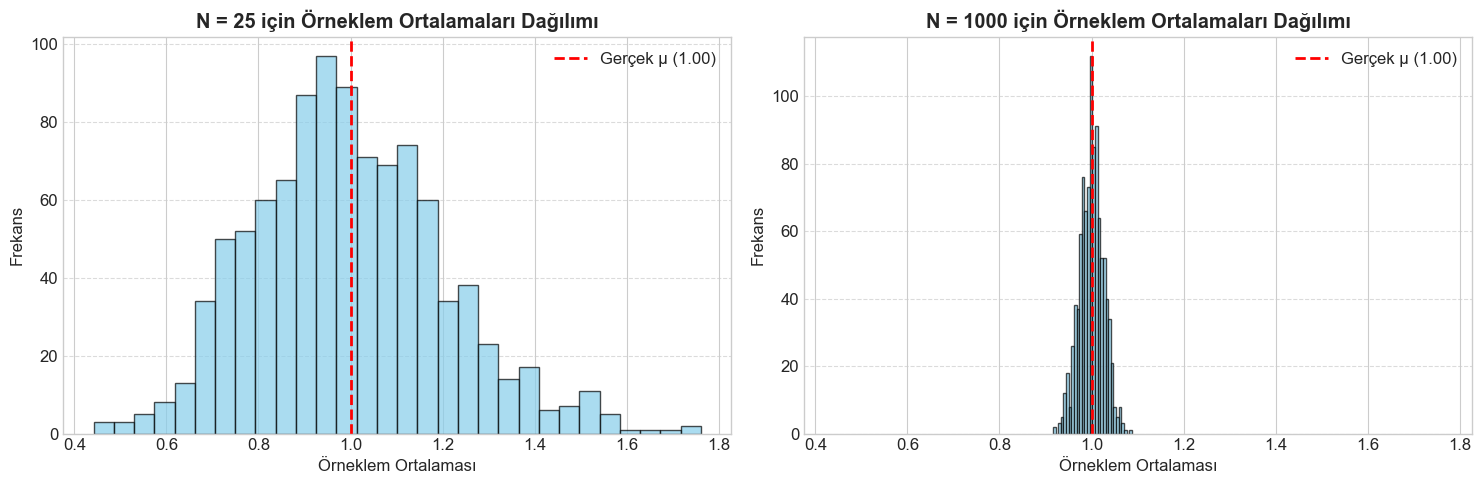

In [11]:
print("\n ==== Egzersiz 3a: ANES Anket Verisi ile Örneklem Ortalaması Çalışması ====")
anes = pd.read_csv('data/anes_timeseries_2024_csv_20260519.csv', low_memory=False)

# Rastgele seçmen ağırlık değişken veya ölçek (V240103b)
valid_weights = pd.to_numeric(anes['V240103b'], errors='coerce').dropna()  # Hatalı değerleri NaN yapar, dropna() ile temizleriz
valid_weights = valid_weights[valid_weights > 0]  # Negatif veya sıfır değerleri filtrele

pop_mean = valid_weights.mean()
pop_size = len(valid_weights)
pop_std = valid_weights.std()
standard_error = pop_std / np.sqrt(pop_size)

print(f"Popülasyon Boyutu: {pop_size} kişi")
print(f"Gerçek Popülasyon Ortalaması (μ): {pop_mean:.4f}")
print(f"Popülasyon Standart Sapması (σ): {pop_std:.4f}")
print(f"Standart Hata (SE): {standard_error:.4f}")

print("\n ==== Egzersiz 3b: Örneklem Boyutu Artarken Örneklem Ortalamalarının Dağılımı ====")

n_sample_sizes = [25, 1000]
means_by_size = []

np.random.seed(42)
for n in n_sample_sizes:
    # 1000 farklı rastgele anket simüle et
    sample_means = [
        np.random.choice(valid_weights, size=n, replace=False).mean()
        for _ in range(1000)
    ]
    means_by_size.append(sample_means)

    # Simülasyonun standart hatası direkt olarak ortalamaların standart sapmasıdır.
    sim_se = np.std(sample_means)
    # Teorik standart hata ise formülle bulunur
    theoretical_se = pop_std / np.sqrt(n)

    print(f"Örneklem Boyutu N={n}:")
    print(f"  - Ortalamaların Ortalaması: {np.mean(sample_means):.4f}")
    print(f"  - Simülasyon Standart Hatası (SE): {sim_se:.4f}")
    print(f"  - Teorik Standart Hata (σ/√n): {theoretical_se:.4f}\n")

# ==== Görselleştirme: Dağılımların Karşılaştırılması ====
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

for i, n in enumerate(n_sample_sizes):
    axes[i].hist(
        means_by_size[i], bins=30, color="skyblue", edgecolor="black", alpha=0.7
    )
    axes[i].axvline(
        pop_mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Gerçek μ ({pop_mean:.2f})",
    )
    axes[i].set_title(
        f"N = {n} için Örneklem Ortalamaları Dağılımı", fontweight="bold"
    )
    axes[i].set_xlabel("Örneklem Ortalaması")
    axes[i].set_ylabel("Frekans")
    axes[i].legend()
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


---
### E4 — Cauchy Dağılımı İstisnası ve SQL Analizi
a) Python `scipy.stats.cauchy` dağılımından $N=50,000$ adet değer üretip kümülatif ortalamasını çizdir. Neden Normal veya Poisson dağılımı gibi düz bir çizgiye oturmadığını, Cauchy'nin yoğunluk fonksiyonunun ($f(x) = \frac{1}{\pi(1+x^2)}$) neden ağır kuyruklu olduğunu ve LLN şartını ($E[|X|] < \infty$) ihlal ettiğini açıkla.

b) SQL (DuckDB) kullanarak 10000 elemanlı Normal Dağılım verisi ile 10000 elemanlı Cauchy Dağılım verisinin kümülatif ortalamasını `AVG() OVER (...)` ile tek bir sorguda yan yana getirip ilk 10 ve son 10 satırı karşılaştır.


 ==== Egzersiz 4a: Cauchy Kümülatif Ortalaması


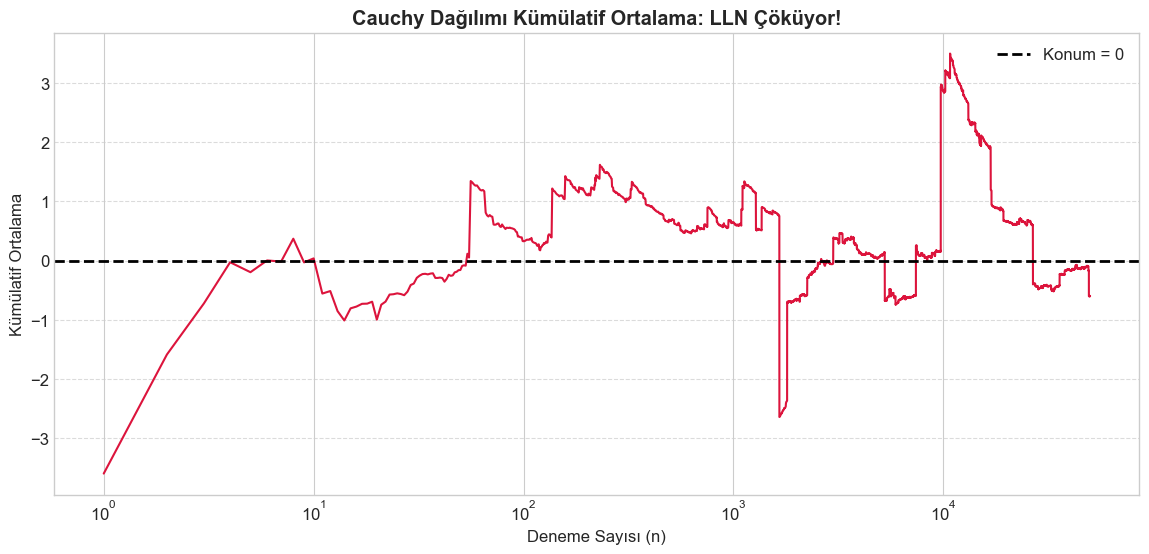

In [12]:
print("\n ==== Egzersiz 4a: Cauchy Kümülatif Ortalaması")
np.random.seed(42)
N = 50000

# Cauchy Dağılımı: Konum = 0, Ölçek = 1
cauchy_samples = np.random.standard_cauchy(size=N)
# Kümülatif Ortalama Hesaplaması
cauchy_cum_mean = np.cumsum(cauchy_samples) / np.arange(1, N + 1)

plt.figure(figsize=(14, 6))
plt.plot(np.arange(1, N + 1), cauchy_cum_mean, color="crimson", lw=1.5)
plt.axhline(0, color="black", linestyle="--", lw=2, label="Konum = 0")
plt.title("Cauchy Dağılımı Kümülatif Ortalama: LLN Çöküyor!", fontweight="bold")
plt.xlabel("Deneme Sayısı (n)")
plt.ylabel("Kümülatif Ortalama")
plt.xscale("log")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [13]:
print("\n ==== Egzersiz 4b: Normal ve Cauchy Dağılımları ile Kümülatif Ortalama Karşılaştırması ====")
np.random.seed(42)
n_sim = 10000
sim_df = pd.DataFrame({
    'idx': np.arange(1, n_sim + 1),
    'normal_val': np.random.normal(0, 1, n_sim),
    'cauchy_val': stats.cauchy.rvs(0, 1, n_sim, random_state=42)
})
con.register('sim_tbl', sim_df)

sql_e4b = con.execute("""
    SELECT
        idx,
        ROUND(AVG(normal_val) OVER (ORDER BY idx ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW), 4) AS normal_cum_avg,
        ROUND(AVG(cauchy_val) OVER (ORDER BY idx ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW), 4) AS cauchy_cum_avg
    FROM sim_tbl
    ORDER BY idx
""").df()

print("=== İLK 20 SATIR ===")
print(sql_e4b.head(20).to_string(index=False))
print("\n=== SON 20 SATIR ===")
print(sql_e4b.tail(20).to_string(index=False))
print("\nYORUM: normal_cum_avg 0'a kilitleniyor; cauchy_cum_avg 1000. satırda bile sıçrama yapabiliyor.")



 ==== Egzersiz 4b: Normal ve Cauchy Dağılımları ile Kümülatif Ortalama Karşılaştırması ====
=== İLK 20 SATIR ===
 idx  normal_cum_avg  cauchy_cum_avg
   1          0.4967         -0.4159
   2          0.1792          2.9954
   3          0.3354          2.2946
   4          0.6323          1.8010
   5          0.4590          1.0660
   6          0.3435          0.5759
   7          0.5200         -0.2806
   8          0.5509          0.0341
   9          0.4376          0.0668
  10          0.4481          0.1368
  11          0.3652         -1.2795
  12          0.2960         -0.2939
  13          0.2918         -0.1390
  14          0.1343         -0.2197
  15          0.0103         -0.3088
  16         -0.0254         -0.3857
  17         -0.0835         -0.4046
  18         -0.0614         -0.3778
  19         -0.1060         -0.3693
  20         -0.1713         -0.3893

=== SON 20 SATIR ===
  idx  normal_cum_avg  cauchy_cum_avg
 9981         -0.0018         -5.0662
 9982      

---
### E5 — LLN'yi Farklı Bir Dağılımla Test Et
`rpois(n=5000, lambda=4)` ile Poisson örneklemi üret, `cummean()` ile kümülatif ortalamayı hesapla ve teorik $\lambda=4$ çizgisiyle karşılaştır (zar örneğindeki gibi).

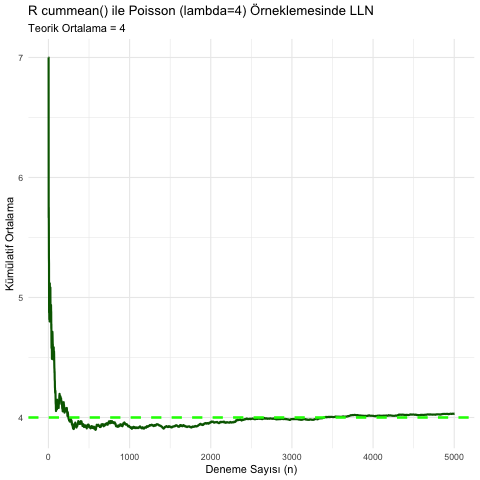

In [14]:
%%R
library(ggplot2)
library(dplyr)
set.seed(42)

N <- 5000
pois_samples <- rpois(N, lambda = 4)
cum_avg_pois <- cummean(pois_samples)
df_pois <- data.frame(Trial = 1:N, CumAvg = cum_avg_pois)

p <- ggplot(df_pois, aes(x = Trial, y = CumAvg)) +
  geom_line(color = "darkgreen", size = 1) +
  geom_hline(yintercept = 4, color = "green", linetype = "dashed", size = 1.2) +
  labs(title = "R cummean() ile Poisson (lambda=4) Örneklemesinde LLN",
       subtitle = "Teorik Ortalama = 4",
       x = "Deneme Sayısı (n)", y = "Kümülatif Ortalama") +
  theme_minimal()

print(p)


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 6 | Law of Large Numbers |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | Ders 29 | LLN, CLT'ye giriş |
| [Seeing Theory](https://seeing-theory.brown.edu/basic-probability/index.html#section3) | Law of Large Numbers | İnteraktif simülasyon |
| [ANES Data Center](https://electionstudies.org/data-center/) | Veri | ANES veri dokümantasyonu |